<a href="https://colab.research.google.com/github/Ecesu893/recycle/blob/main/copAyristirma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow albumentations -q

import os, cv2, shutil, random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import albumentations as A
from PIL import Image, ImageFilter, ImageEnhance
from pathlib import Path
from google.colab import drive

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB3, ResNet50V2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

IMG_SIZE, BATCH_SIZE, EPOCHS, SEED = 224, 32, 15, 42
np.random.seed(SEED); tf.random.set_seed(SEED)
print("GPU:", tf.config.list_physical_devices('GPU'))

GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
drive.mount('/content/drive')

DATASET_PATH  = '/content/drive/MyDrive/Atiklar'   # <-- KENDİ YOLUN
AUGMENTED_PATH = '/content/augmented'
SPLIT_PATH     = '/content/split'

CLASSES = sorted([d for d in os.listdir(DATASET_PATH) if os.path.isdir(f'{DATASET_PATH}/{d}')])
print("Sınıflar:", CLASSES)
for cls in CLASSES:
    print(f"  {cls}: {len(os.listdir(f'{DATASET_PATH}/{cls}'))} görüntü")

Mounted at /content/drive
Sınıflar: ['cam', 'kagit', 'metal', 'organik', 'pil', 'plastik']
  cam: 120 görüntü
  kagit: 120 görüntü
  metal: 120 görüntü
  organik: 120 görüntü
  pil: 120 görüntü
  plastik: 120 görüntü


In [3]:
TRANSFORMS = [
    A.ElasticTransform(alpha=120, sigma=6, alpha_affine=3.6, p=1.0),
    A.GridDistortion(num_steps=5, distort_limit=0.3, p=1.0),
    A.OpticalDistortion(distort_limit=0.5, p=1.0),
    A.CLAHE(clip_limit=4.0, p=1.0),
    A.CoarseDropout(max_holes=8, max_height=30, max_width=30, p=1.0),
    A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=15, blur_value=3, p=1.0),
    A.RandomShadow(p=1.0),
    A.Perspective(scale=(0.05, 0.15), p=1.0),
    A.Compose([A.GaussNoise(var_limit=(50,150), p=1.0), A.MotionBlur(blur_limit=7, p=0.5)]),
    A.ChannelShuffle(p=1.0),
]

def pil_augment(img_np):
    pil = Image.fromarray(img_np)
    sharp = ImageEnhance.Sharpness(pil).enhance(3.0)
    bright = ImageEnhance.Brightness(sharp).enhance(1.4)
    embossed = pil.filter(ImageFilter.EMBOSS).convert('RGB')
    return [np.array(bright), np.array(embossed)]

# --- Augment ---
if os.path.exists(AUGMENTED_PATH): shutil.rmtree(AUGMENTED_PATH)
for cls in CLASSES:
    os.makedirs(f'{AUGMENTED_PATH}/{cls}')
    for fname in os.listdir(f'{DATASET_PATH}/{cls}'):
        img = cv2.cvtColor(cv2.imread(f'{DATASET_PATH}/{cls}/{fname}'), cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        stem = Path(fname).stem
        Image.fromarray(img).save(f'{AUGMENTED_PATH}/{cls}/{stem}_orig.jpg')
        for i, t in enumerate(TRANSFORMS):
            aug = cv2.resize(t(image=img)['image'], (IMG_SIZE, IMG_SIZE))
            Image.fromarray(aug.astype(np.uint8)).save(f'{AUGMENTED_PATH}/{cls}/{stem}_a{i}.jpg')
        for i, pil_img in enumerate(pil_augment(img)):
            Image.fromarray(pil_img).save(f'{AUGMENTED_PATH}/{cls}/{stem}_p{i}.jpg')
    count = len(os.listdir(f'{AUGMENTED_PATH}/{cls}'))
    print(f"{cls}: {count} görüntü")

# --- Split (70/15/15) ---
if os.path.exists(SPLIT_PATH): shutil.rmtree(SPLIT_PATH)
for split in ['train','val','test']:
    for cls in CLASSES:
        os.makedirs(f'{SPLIT_PATH}/{split}/{cls}')

for cls in CLASSES:
    imgs = sorted(os.listdir(f'{AUGMENTED_PATH}/{cls}'))
    random.seed(SEED); random.shuffle(imgs)
    n = len(imgs)
    n_test = int(n*0.15); n_val = int(n*0.15)
    for i, (split, chunk) in enumerate([
        ('train', imgs[:n-n_test-n_val]),
        ('val',   imgs[n-n_test-n_val:-n_test]),
        ('test',  imgs[-n_test:])
    ]):
        for f in chunk:
            shutil.copy(f'{AUGMENTED_PATH}/{cls}/{f}', f'{SPLIT_PATH}/{split}/{cls}/{f}')
    print(f"{cls}: train={n-n_test-n_val}, val={n_val}, test={n_test}")

/tmp/ipykernel_1425/1088208460.py:2: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=120, sigma=6, alpha_affine=3.6, p=1.0),
/tmp/ipykernel_1425/1088208460.py:6: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=30, max_width=30, p=1.0),
/tmp/ipykernel_1425/1088208460.py:7: UserWarning: Argument(s) 'slant_lower, slant_upper' are not valid for transform RandomRain
  A.RandomRain(slant_lower=-10, slant_upper=10, drop_length=15, blur_value=3, p=1.0),
/tmp/ipykernel_1425/1088208460.py:10: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.Compose([A.GaussNoise(var_limit=(50,150), p=1.0), A.MotionBlur(blur_limit=7, p=0.5)]),


cam: 1560 görüntü
kagit: 1560 görüntü
metal: 1560 görüntü
organik: 1560 görüntü
pil: 1560 görüntü
plastik: 1560 görüntü
cam: train=1092, val=234, test=234
kagit: train=1092, val=234, test=234
metal: train=1092, val=234, test=234
organik: train=1092, val=234, test=234
pil: train=1092, val=234, test=234
plastik: train=1092, val=234, test=234


In [7]:
from tensorflow.keras.applications.efficientnet import preprocess_input as eff_preprocess
from tensorflow.keras.applications.resnet_v2 import preprocess_input as res_preprocess

eff_gen = ImageDataGenerator(preprocessing_function=eff_preprocess)
res_gen = ImageDataGenerator(preprocessing_function=res_preprocess)

eff_train = eff_gen.flow_from_directory(f'{SPLIT_PATH}/train', target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED)
eff_val   = eff_gen.flow_from_directory(f'{SPLIT_PATH}/val',   target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
eff_test  = eff_gen.flow_from_directory(f'{SPLIT_PATH}/test',  target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

res_train = res_gen.flow_from_directory(f'{SPLIT_PATH}/train', target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', seed=SEED)
res_val   = res_gen.flow_from_directory(f'{SPLIT_PATH}/val',   target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)
res_test  = res_gen.flow_from_directory(f'{SPLIT_PATH}/test',  target_size=(IMG_SIZE,IMG_SIZE), batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False)

NUM_CLASSES = len(CLASSES)
print("Sınıf sayısı:", NUM_CLASSES)
print("Sınıflar:", eff_train.class_indices)

Found 6552 images belonging to 6 classes.
Found 1404 images belonging to 6 classes.
Found 1404 images belonging to 6 classes.
Found 6552 images belonging to 6 classes.
Found 1404 images belonging to 6 classes.
Found 1404 images belonging to 6 classes.
Sınıf sayısı: 6
Sınıflar: {'cam': 0, 'kagit': 1, 'metal': 2, 'organik': 3, 'pil': 4, 'plastik': 5}


In [8]:
def build_model(base_fn, name):
    base = base_fn(weights='imagenet', include_top=False, input_shape=(IMG_SIZE,IMG_SIZE,3))
    base.trainable = False
    inp = tf.keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))
    x = base(inp, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    m = models.Model(inp, out, name=name)
    m.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='categorical_crossentropy', metrics=['accuracy'])
    return m, base

eff_model, eff_base = build_model(EfficientNetB3, 'EfficientNetB3')
res_model, res_base = build_model(ResNet50V2,    'ResNet50V2')

In [9]:
def train(model, base, name, train_gen, val_gen):
    cbs = [EarlyStopping(monitor='val_accuracy', patience=4, restore_best_weights=True),
           ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-7),
           ModelCheckpoint(f'/content/{name}_best.h5', monitor='val_accuracy', save_best_only=True)]

    print(f"\n=== {name} — Aşama 1: Freeze ===")
    h1 = model.fit(train_gen, validation_data=val_gen, epochs=8, callbacks=cbs)

    base.trainable = True
    for layer in base.layers[:-30]: layer.trainable = False
    model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])

    print(f"\n=== {name} — Aşama 2: Fine-tune ===")
    h2 = model.fit(train_gen, validation_data=val_gen, epochs=15, callbacks=cbs)

    history = {k: h1.history[k] + h2.history[k] for k in h1.history}
    return history

eff_hist = train(eff_model, eff_base, 'efficientnet', eff_train, eff_val)
res_hist = train(res_model, res_base, 'resnet', res_train, res_val)


=== efficientnet — Aşama 1: Freeze ===
Epoch 1/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step - accuracy: 0.6866 - loss: 1.0086

205/205 ━━━━━━━━━━━━━━━━━━━━ 102s 310ms/step - accuracy: 0.7862 - loss: 0.6833 - val_accuracy: 0.9259 - val_loss: 0.2058 - learning_rate: 0.0010
Epoch 2/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.8864 - loss: 0.3179

205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.8886 - loss: 0.3261 - val_accuracy: 0.9444 - val_loss: 0.1550 - learning_rate: 0.0010
Epoch 3/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 19s 93ms/step - accuracy: 0.9177 - loss: 0.2262 - val_accuracy: 0.9395 - val_loss: 0.1518 - learning_rate: 0.0010
Epoch 4/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 19s 90ms/step - accuracy: 0.9275 - loss: 0.1935 - val_accuracy: 0.9437 - val_loss: 0.1382 - learning_rate: 0.0010
Epoch 5/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9355 - loss: 0.1735

205/205 ━━━━━━━━━━━━━━━━━━━━ 19s 94ms/step - accuracy: 0.9364 - loss: 0.1777 - val_accuracy: 0.9480 - val_loss: 0.1316 - learning_rate: 0.0010
Epoch 6/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9468 - loss: 0.1496

205/205 ━━━━━━━━━━━━━━━━━━━━ 21s 104ms/step - accuracy: 0.9412 - loss: 0.1629 - val_accuracy: 0.9494 - val_loss: 0.1284 - learning_rate: 0.0010
Epoch 7/8
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.9482 - loss: 0.1358

...

205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.9791 - loss: 0.0609 - val_accuracy: 0.9637 - val_loss: 0.1048 - learning_rate: 1.0000e-05
Epoch 6/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9817 - loss: 0.0542

205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 137ms/step - accuracy: 0.9820 - loss: 0.0551 - val_accuracy: 0.9651 - val_loss: 0.1022 - learning_rate: 1.0000e-05
Epoch 7/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - accuracy: 0.9853 - loss: 0.0456 - val_accuracy: 0.9651 - val_loss: 0.1005 - learning_rate: 1.0000e-05
Epoch 8/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - accuracy: 0.9866 - loss: 0.0386

205/205 ━━━━━━━━━━━━━━━━━━━━ 30s 147ms/step - accuracy: 0.9882 - loss: 0.0350 - val_accuracy: 0.9672 - val_loss: 0.0980 - learning_rate: 1.0000e-05
Epoch 9/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.9919 - loss: 0.0296 - val_accuracy: 0.9658 - val_loss: 0.0944 - learning_rate: 1.0000e-05
Epoch 10/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9949 - loss: 0.0200

205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 138ms/step - accuracy: 0.9936 - loss: 0.0200 - val_accuracy: 0.9679 - val_loss: 0.0950 - learning_rate: 1.0000e-05
Epoch 11/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step - accuracy: 0.9933 - loss: 0.0207

205/205 ━━━━━━━━━━━━━━━━━━━━ 34s 167ms/step - accuracy: 0.9934 - loss: 0.0202 - val_accuracy: 0.9694 - val_loss: 0.0943 - learning_rate: 1.0000e-05
Epoch 12/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 28s 134ms/step - accuracy: 0.9933 - loss: 0.0217 - val_accuracy: 0.9679 - val_loss: 0.0927 - learning_rate: 3.0000e-06
Epoch 13/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - accuracy: 0.9950 - loss: 0.0167 - val_accuracy: 0.9687 - val_loss: 0.0922 - learning_rate: 3.0000e-06
Epoch 14/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 27s 132ms/step - accuracy: 0.9959 - loss: 0.0158 - val_accuracy: 0.9687 - val_loss: 0.0918 - learning_rate: 3.0000e-06
Epoch 15/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 27s 134ms/step - accuracy: 0.9960 - loss: 0.0146 - val_accuracy: 0.9687 - val_loss: 0.0897 - learning_rate: 3.0000e-06


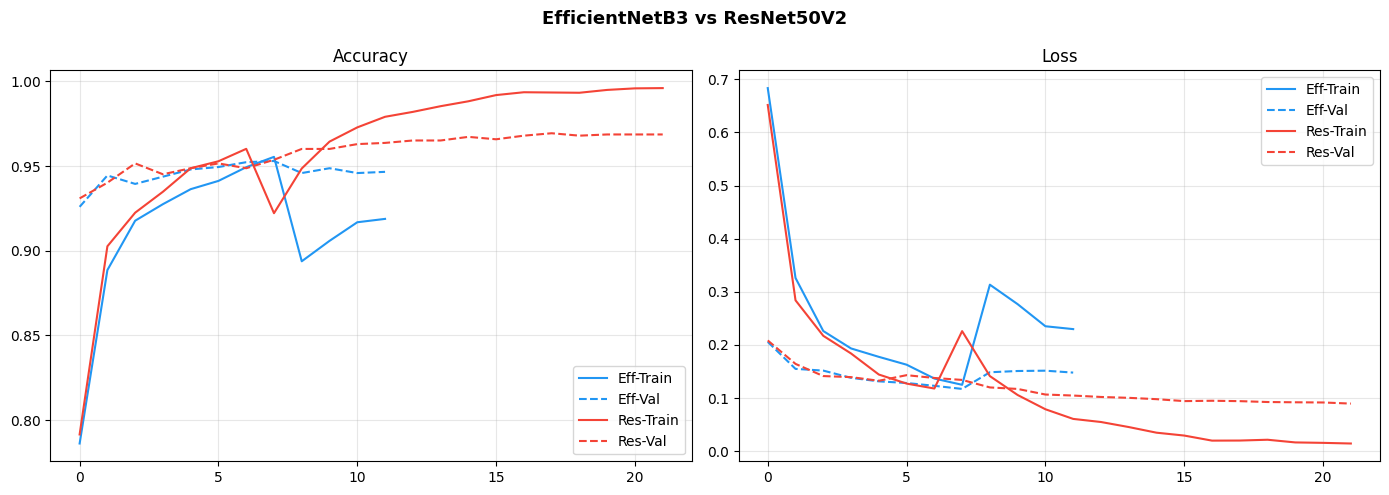

44/44 ━━━━━━━━━━━━━━━━━━━━ 25s 336ms/step

EfficientNetB3
               precision    recall  f1-score   support

         cam       0.96      0.92      0.94       234
       kagit       0.91      0.96      0.94       234
       metal       0.94      0.95      0.94       234
     organik       0.97      0.98      0.98       234
         pil       1.00      0.98      0.99       234
     plastik       0.91      0.90      0.90       234

    accuracy                           0.95      1404
   macro avg       0.95      0.95      0.95      1404
weighted avg       0.95      0.95      0.95      1404

44/44 ━━━━━━━━━━━━━━━━━━━━ 10s 161ms/step

ResNet50V2
               precision    recall  f1-score   support

         cam       0.97      0.95      0.96       234
       kagit       0.97      0.98      0.97       234
       metal       0.95      0.98      0.96       234
     organik       0.99      0.98      0.99       234
         pil       0.99      1.00      0.99       234
     plastik      

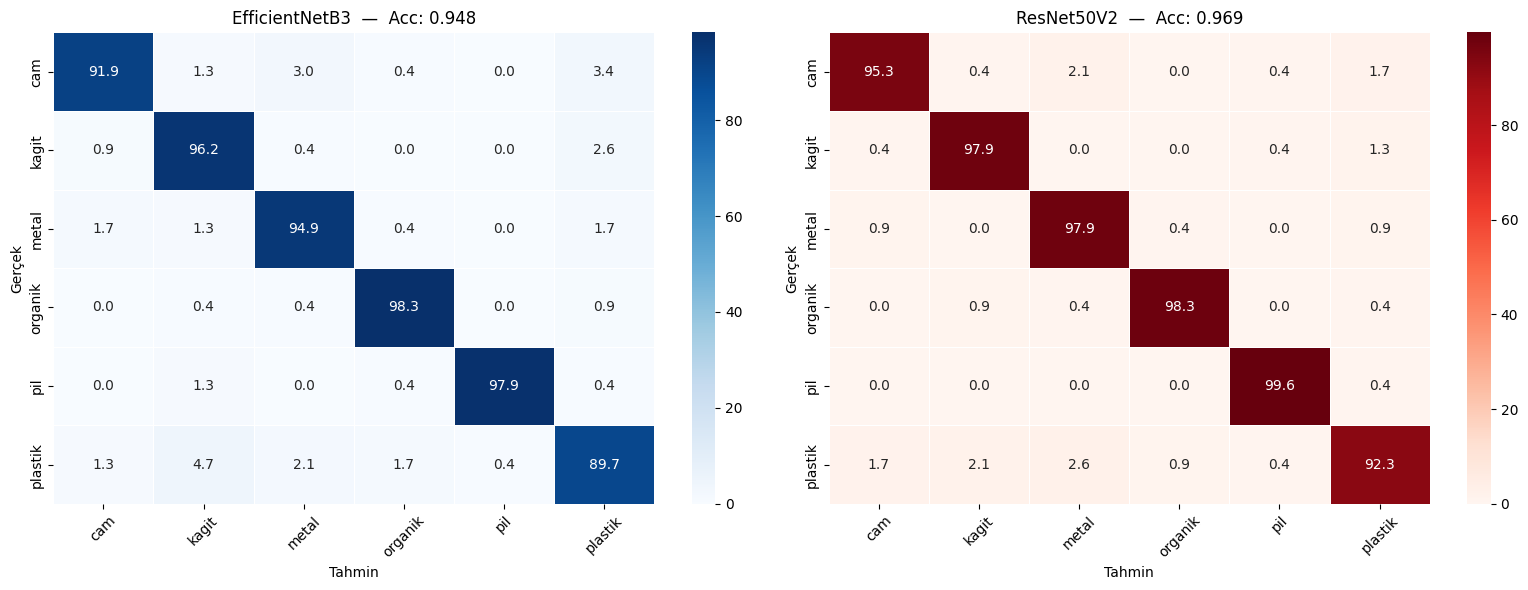

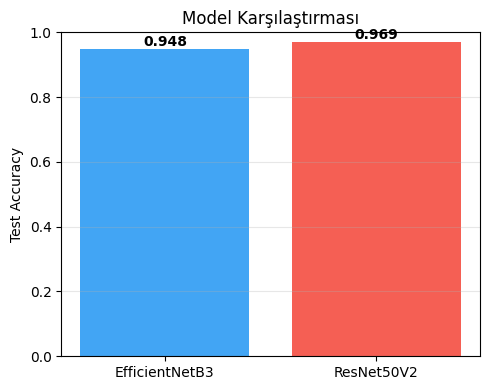

In [10]:
# Eğitim eğrileri
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('EfficientNetB3 vs ResNet50V2', fontsize=13, fontweight='bold')
for ax, metric, title in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(eff_hist[metric],          color='#2196F3', label='Eff-Train')
    ax.plot(eff_hist[f'val_{metric}'], color='#2196F3', linestyle='--', label='Eff-Val')
    ax.plot(res_hist[metric],          color='#F44336', label='Res-Train')
    ax.plot(res_hist[f'val_{metric}'], color='#F44336', linestyle='--', label='Res-Val')
    ax.set_title(title); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/content/training_curves.png', dpi=150); plt.show()

# Confusion matrix + Classification report
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
results = {}
for ax, model, test_gen, name, cmap in [
    (axes[0], eff_model, eff_test, 'EfficientNetB3', 'Blues'),
    (axes[1], res_model, res_test, 'ResNet50V2',     'Reds')
]:
    test_gen.reset()
    preds = np.argmax(model.predict(test_gen), axis=1)
    y_true = test_gen.classes
    acc = (preds == y_true).mean()
    results[name] = acc
    cm = confusion_matrix(y_true, preds)
    cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100
    sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap=cmap, ax=ax,
                xticklabels=CLASSES, yticklabels=CLASSES, linewidths=0.5)
    ax.set_title(f'{name}  —  Acc: {acc:.3f}')
    ax.set_xlabel('Tahmin'); ax.set_ylabel('Gerçek')
    ax.tick_params(axis='x', rotation=45)
    print(f"\n{name}\n", classification_report(y_true, preds, target_names=CLASSES))

plt.tight_layout()
plt.savefig('/content/confusion_matrices.png', dpi=150); plt.show()

# Özet bar chart
fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(results.keys(), results.values(), color=['#2196F3','#F44336'], alpha=0.85)
ax.set_ylim(0, 1); ax.set_ylabel('Test Accuracy'); ax.set_title('Model Karşılaştırması')
for i, (name, val) in enumerate(results.items()):
    ax.text(i, val + 0.01, f'{val:.3f}', ha='center', fontweight='bold')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/model_comparison.png', dpi=150); plt.show()

In [11]:
eff_model.save('/content/efficientnet_final.keras')
res_model.save('/content/resnet_final.keras')
print("Modeller kaydedildi.")

Modeller kaydedildi.


In [12]:
out = '/content/drive/MyDrive/cop_sonuclari'
os.makedirs(out, exist_ok=True)
for f in ['training_curves.png', 'confusion_matrices.png', 'model_comparison.png',
          'efficientnet_best.h5', 'resnet_best.h5',
          'efficientnet_final.keras', 'resnet_final.keras']:
    if os.path.exists(f'/content/{f}'):
        shutil.copy(f'/content/{f}', f'{out}/{f}')
        print("Kaydedildi:", f)

Kaydedildi: training_curves.png
Kaydedildi: confusion_matrices.png
Kaydedildi: model_comparison.png
Kaydedildi: efficientnet_best.h5
Kaydedildi: resnet_best.h5
Kaydedildi: efficientnet_final.keras
Kaydedildi: resnet_final.keras


Saving plastic703.jpg to plastic703.jpg


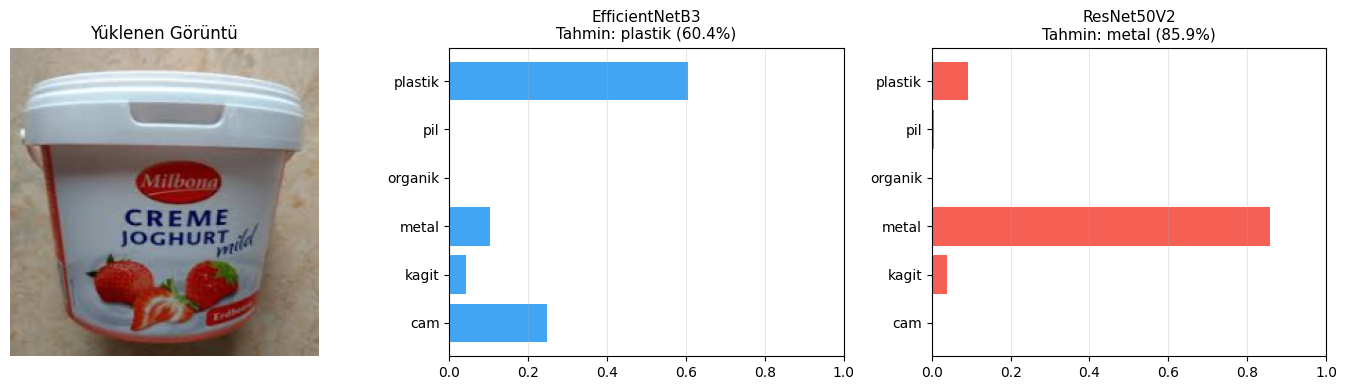

EfficientNetB3 → plastik (60.4%)
ResNet50V2     → metal (85.9%)


In [13]:
from google.colab import files
from tensorflow import keras

# Modelleri yükle (zaten memorydeyse bu satırları atlayabilirsin)
# eff_model = keras.models.load_model('/content/drive/MyDrive/cop_sonuclari/efficientnet_final.keras')
# res_model = keras.models.load_model('/content/drive/MyDrive/cop_sonuclari/resnet_final.keras')

# Görüntü yükle
uploaded = files.upload()
img_path = list(uploaded.keys())[0]

# Ön işleme
img = cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

from tensorflow.keras.applications.efficientnet import preprocess_input as eff_pre
from tensorflow.keras.applications.resnet_v2 import preprocess_input as res_pre

eff_input = np.expand_dims(eff_pre(img.astype(np.float32)), axis=0)
res_input = np.expand_dims(res_pre(img.astype(np.float32)), axis=0)

# Tahmin
eff_pred = eff_model.predict(eff_input, verbose=0)[0]
res_pred = res_model.predict(res_input, verbose=0)[0]

eff_class = CLASSES[np.argmax(eff_pred)]
res_class = CLASSES[np.argmax(res_pred)]

# Göster
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].imshow(img)
axes[0].set_title('Yüklenen Görüntü', fontsize=12)
axes[0].axis('off')

axes[1].barh(CLASSES, eff_pred, color='#2196F3', alpha=0.85)
axes[1].set_title(f'EfficientNetB3\nTahmin: {eff_class} ({eff_pred.max()*100:.1f}%)', fontsize=11)
axes[1].set_xlim(0, 1)
axes[1].grid(axis='x', alpha=0.3)

axes[2].barh(CLASSES, res_pred, color='#F44336', alpha=0.85)
axes[2].set_title(f'ResNet50V2\nTahmin: {res_class} ({res_pred.max()*100:.1f}%)', fontsize=11)
axes[2].set_xlim(0, 1)
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('/content/tahmin_sonucu.png', dpi=150)
plt.show()

print(f"EfficientNetB3 → {eff_class} ({eff_pred.max()*100:.1f}%)")
print(f"ResNet50V2     → {res_class} ({res_pred.max()*100:.1f}%)")